# Customer Segmentation

We cluster customers along two independent perspectives that combine into a final segment, and we also compute a demographic perspective as descriptive context.

1. **Value** — how engaged and high-spending the customer is, regardless of what they buy
2. **Product mix** — relative shares of spend across categories, regardless of how much they spend overall
3. **Demographics** (descriptive only) — age, household, education, hour, loyalty

Splitting the features this way produces clusters that can be described in plain language ("engaged tech enthusiast" or "promo hunter"). A single all-features clustering tends to mix these dimensions and produce groups that are harder to name and harder to act on.

For each perspective we:

- scale the features
- choose K using inertia, silhouette, Davies-Bouldin and Calinski-Harabasz
- cross-check K-Means against hierarchical (Ward) clustering
- run a stability check across multiple random seeds (Adjusted Rand Index between runs)
- profile the clusters and assign each one a content-based name

We then build the final segment label from the *named* value and mix clusters, fold tiny segments back into their generalist counterparts (any segment with fewer than 200 customers is too small to support a real campaign), and save the result.

The demographic perspective is computed and reported because the brief asks for demographic analysis, but the analysis below shows it essentially recovers the `degree` feature in this dataset. **It is therefore not used as a primary axis in the final segment assignment, not persisted with the other models, and not included in `customer_segments.csv`.** Its value is in confirming a finding about the data, not in segmenting customers.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
# Silence only the two known-noisy third-party categories rather than every
# warning: a blanket ignore hides real deprecations until they become errors.
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing as pp
from src import clustering as clu
from src import baselines as bl
from src import visualization as viz
from src import config as cfg

viz.set_style()
pd.set_option("display.max_columns", 60)

FIG_DIR = cfg.FIGURE_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=120, bbox_inches="tight")

In [2]:
raw = pp.load_customer_info()
df, preproc_params = pp.build_features_with_params(raw)
print("Shape:", df.shape)
print("Frozen preprocessing params:",
      f"{len(preproc_params['medians'])} medians, {len(preproc_params['caps'])} spend caps")

Shape: (33038, 49)
Frozen preprocessing params: 4 medians, 9 spend caps


## 1. Value perspective

Features: log-total-spend, distinct products bought, distinct stores visited, tenure in years, promo percentage.

This captures *how much* a customer engages with us. We expect at least a high/low engagement split, and possibly a separate "deal-hunting" group whose promo percentage is high regardless of overall spend.

In [3]:
scaler_v, Xv = clu.scale_perspective(df, cfg.VALUE_FEATURES)
print("Value features:", cfg.VALUE_FEATURES)
print("Scaled matrix shape:", Xv.shape)

Value features: ['total_spend_log', 'lifetime_total_distinct_products', 'distinct_stores_visited', 'tenure_years', 'promo_pct']
Scaled matrix shape: (33038, 5)


### Choosing K

In [4]:
metrics_v = clu.evaluate_k_range(Xv, k_range=range(2, 9))
metrics_v.round(3)

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,128713.334,0.233,1.694,9362.287
3,105074.836,0.242,1.479,9449.981
4,91834.861,0.229,1.441,8795.580
5,83849.663,0.185,1.432,8011.155
6,77424.464,0.188,1.512,7488.786
7,73192.407,0.180,1.458,6919.632
8,69210.461,0.180,1.513,6543.653


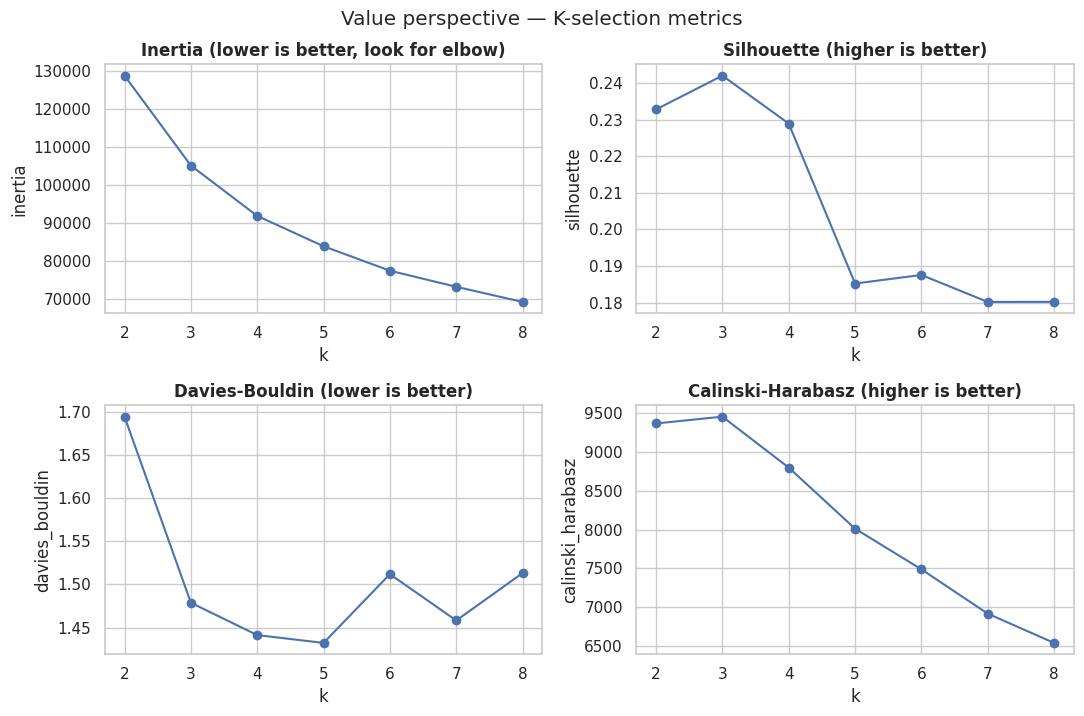

In [5]:
viz.plot_k_metrics(metrics_v)
plt.suptitle("Value perspective — K-selection metrics", y=1.02)
save_fig(plt.gcf(), "16_value_k_metrics")
plt.show()

Silhouette peaks at K=3, Davies-Bouldin shows its first big drop at K=3, and there is a visible inertia elbow at 3. We pick **K=3**.

In [6]:
K_VALUE = 3
km_v, labels_v = clu.fit_kmeans(Xv, n_clusters=K_VALUE)
df["value_cluster"] = labels_v
clu.cluster_sizes(labels_v)

0    17109
1     6999
2     8930
Name: count, dtype: int64

### Stability check

K-Means is sensitive to initial centroids. We refit with six different random seeds and compute pairwise Adjusted Rand Index between runs. ARI close to 1 means the customer partition is essentially identical across seeds, even if integer labels shuffle.

In [7]:
stab_v = clu.stability_across_seeds(Xv, n_clusters=K_VALUE)
print(f"Mean pairwise ARI across 6 seeds: {stab_v['mean_ari']:.4f}")
print(f"Min pairwise ARI:                  {stab_v['min_ari']:.4f}")
print(f"Std pairwise ARI:                  {stab_v['std_ari']:.4f}")

Mean pairwise ARI across 6 seeds: 0.9970
Min pairwise ARI:                  0.9951
Std pairwise ARI:                  0.0014


ARI > 0.99 across all pairs. The partition is highly stable; only the integer labels can shuffle, and we handle that with content-based naming below.

### Cluster profile and content-based naming

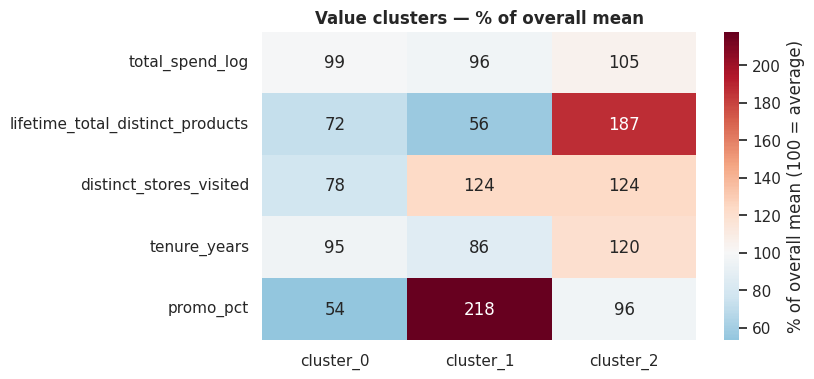

,cluster_0,cluster_1,cluster_2
total_spend_log,98.9,95.9,105.3
lifetime_total_distinct_products,72.5,56.5,186.9
distinct_stores_visited,77.8,124.0,123.6
tenure_years,95.2,86.1,120.1
promo_pct,53.6,217.9,96.5


In [8]:
profile_v = clu.cluster_profile(df, labels_v, cfg.VALUE_FEATURES)
fig, ax = plt.subplots(figsize=(7, 4))
viz.plot_cluster_heatmap(profile_v, title="Value clusters — % of overall mean", ax=ax)
save_fig(fig, "17_value_profile")
plt.show()
profile_v

In [9]:
value_map = clu.name_value_clusters(df)
print("Cluster ID -> content-based name:")
for cid, name in value_map.items():
    print(f"  cluster {cid} -> {name}")

Cluster ID -> content-based name:
  cluster 1 -> promo_hunter
  cluster 2 -> engaged
  cluster 0 -> routine


The three value clusters break down as follows. Note this axis is engagement and breadth, not total spend:

- **engaged** — the broad-basket customers: highest distinct-product count (around 280, about 2.6x the routine cluster), longest tenure, as many stores visited as the promo hunters, modest promo usage. Mean spend about €37,600, around 60% above the population mean.
- **promo_hunter** — defined by behaviour, not breadth: promo percentage about 0.71 (overall mean ~0.33), wide store-visit pattern (3.9 stores on average), but the lowest mean total spend of the three (~€14,900). These are deal-driven shoppers.
- **routine** — narrow but normal: about 108 distinct products (narrow, though the promo hunters are narrower still), low promo usage (~0.17), visits to ~2.5 stores. Critically, mean total spend is **about €19,800 — roughly 85% of the overall mean, not low.** This cluster looks like habitual, focused shoppers who buy a smaller set of items repeatedly, not customers disengaged from the brand. We deliberately do not call it "low-value" or "low-engagement"; "routine" reflects what the data actually shows.

### Hierarchical cross-check

Hierarchical silhouette at K=3: 0.210
K-Means silhouette at K=3:     0.242


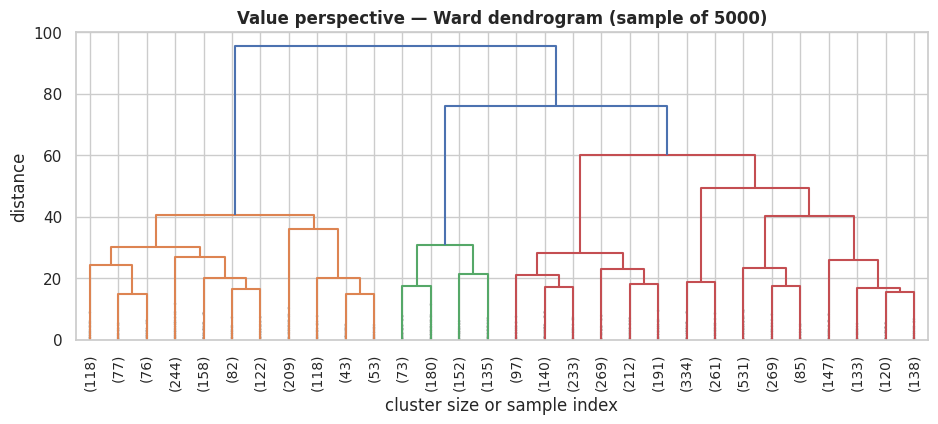

In [10]:
hier_v = clu.hierarchical_validation(Xv, n_clusters=K_VALUE)
print(f"Hierarchical silhouette at K=3: {hier_v['silhouette']:.3f}")
print(f"K-Means silhouette at K=3:     {metrics_v.loc[K_VALUE, 'silhouette']:.3f}")

fig, ax = plt.subplots(figsize=(11, 4))
viz.plot_dendrogram(hier_v["linkage_matrix"], truncate_p=30, ax=ax,
                    title="Value perspective — Ward dendrogram (sample of 5000)")
save_fig(fig, "18_value_dendrogram")
plt.show()

## 1b. Why K-Means and not DBSCAN, Mean-Shift, or a SOM?

A partitional method should be a *choice*, not a default. Density-based (DBSCAN), mode-seeking (Mean-Shift) and self-organising maps are the standard alternatives, so we test the first two on the value perspective and show why they do not suit this data.

The key property of this dataset is that, after scaling, the customers form a single dense cloud rather than several well-separated dense regions. Density-based and mode-seeking methods look for gaps between dense regions; when there are no gaps, they either lump everyone into one cluster or shatter the data into noise. K-Means instead *imposes* a partition, which is what we want when the goal is actionable segments rather than discovering natural density valleys.

### DBSCAN

DBSCAN needs an `eps` radius. The principled way to choose it is the k-distance plot: sort every point's distance to its k-th nearest neighbour (k = 2 x dimensions) and look for the "knee" where the curve turns sharply upward. We plot that curve and then run DBSCAN across the plausible eps range around the knee.

min_samples (2 x dim) = 10


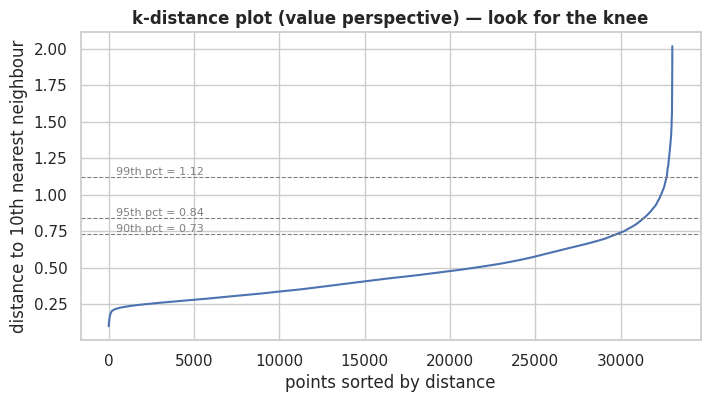

In [11]:
kdist, k_used = clu.k_distance_curve(Xv)
print(f"min_samples (2 x dim) = {k_used}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kdist)
ax.set_xlabel("points sorted by distance")
ax.set_ylabel(f"distance to {k_used}th nearest neighbour")
ax.set_title("k-distance plot (value perspective) — look for the knee")
for p in [90, 95, 99]:
    import numpy as np
    val = np.percentile(kdist, p)
    ax.axhline(val, ls="--", lw=0.8, color="grey")
    ax.text(0, val, f"  {p}th pct = {val:.2f}", va="bottom", fontsize=8, color="grey")
save_fig(fig, "16b_kdistance")
plt.show()

In [12]:
# Scan DBSCAN across eps values spanning the knee region
db_scan = clu.dbscan_scan(Xv, eps_values=[0.6, 0.8, 1.0, 1.5, 2.0], min_samples=k_used)
db_scan

,eps,min_samples,n_clusters,noise_fraction
0,0.6,10,23,0.117441
1,0.8,10,1,0.021188
2,1.0,10,1,0.004631
3,1.5,10,1,0.000030
4,2.0,10,1,0.000000


Read the scan against the k-distance plot. At and above the knee (eps 0.8 and up) DBSCAN returns **a single cluster** holding essentially everything — there is no density valley for it to cut on. Below the knee (eps 0.6) it does not find structure either; it **shatters into 23 micro-clusters and labels 11.7% of customers as noise**, which is a different failure rather than a better result: 23 groups, most of them tiny, with an eighth of the customer base unassigned, is not something a marketing team can act on.

Neither end of the range yields a usable segmentation, and there is no eps in between that does. DBSCAN is the wrong tool for this data.

### Mean-Shift

Mean-Shift seeks modes (peaks) in the density. It is O(n^2) per iteration, so we run it on a 4,000-customer sample with a bandwidth estimated from the data.

In [13]:
ms_value = clu.meanshift_summary(Xv)
print("Mean-Shift on the value perspective (4,000-customer sample):")
print(f"  estimated bandwidth:        {ms_value['bandwidth']:.2f}")
print(f"  clusters found:             {ms_value['n_clusters']}")
print(f"  share in largest cluster:   {ms_value['largest_cluster_fraction']:.0%}")

# Mean-Shift on the product-mix perspective. We scale it here (the product-mix
# section below scales it again for clustering; this keeps section 1b self-contained).
_, Xp_preview = clu.scale_perspective(df, cfg.PRODUCT_MIX_FEATURES)
ms_mix = clu.meanshift_summary(Xp_preview)
print("\nMean-Shift on the product-mix perspective (4,000-customer sample):")
print(f"  estimated bandwidth:        {ms_mix['bandwidth']:.2f}")
print(f"  clusters found:             {ms_mix['n_clusters']}")
print(f"  share in largest cluster:   {ms_mix['largest_cluster_fraction']:.0%}")

Mean-Shift on the value perspective (4,000-customer sample):
  estimated bandwidth:        2.18
  clusters found:             1
  share in largest cluster:   100%



Mean-Shift on the product-mix perspective (4,000-customer sample):
  estimated bandwidth:        2.85
  clusters found:             63
  share in largest cluster:   79%


Mean-Shift confirms the same picture. On the value perspective it finds a single mode (one cluster holding 100% of the sample). On the product-mix perspective it produces one dominant blob holding 79% of customers plus 62 tiny fragments — not a balanced, actionable segmentation either.

### Conclusion

Both density-based and mode-seeking methods agree the data is a single dense mass with no natural separation. That is the empirical justification for a **partitional** approach: K-Means imposes a clean, balanced k-way split that we can name and act on, and hierarchical (Ward) clustering corroborates the K-Means structure. We therefore proceed with K-Means as the primary algorithm, using hierarchical clustering for validation, having explicitly tested and rejected DBSCAN and Mean-Shift with reasons.

**On SOMs:** we did not run one, and the README says so. The reasoning is that a self-organising map is also a structure-imposing method rather than a density-discovering one — a 1xK SOM reduces to essentially the same partition K-Means produces, so it would not test the question this section is asking. That is an argument, not evidence, and it is flagged as such rather than counted alongside the two methods we actually ran.

## 2. Product-mix perspective

Features: the ten `share_*` columns — each category as a fraction of the customer's total spend. Independent of how much someone spends; asks *what* they spend on.

In [14]:
scaler_p, Xp = clu.scale_perspective(df, cfg.PRODUCT_MIX_FEATURES)
metrics_p = clu.evaluate_k_range(Xp, k_range=range(2, 9))
metrics_p.round(3)

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,255195.171,0.395,1.643,9732.968
3,212356.357,0.327,1.364,9180.118
4,185626.894,0.344,1.376,8586.716
5,168686.231,0.222,1.512,7915.926
6,155891.473,0.226,1.477,7394.510
7,146516.242,0.226,1.456,6908.457
8,139522.967,0.227,1.475,6454.655


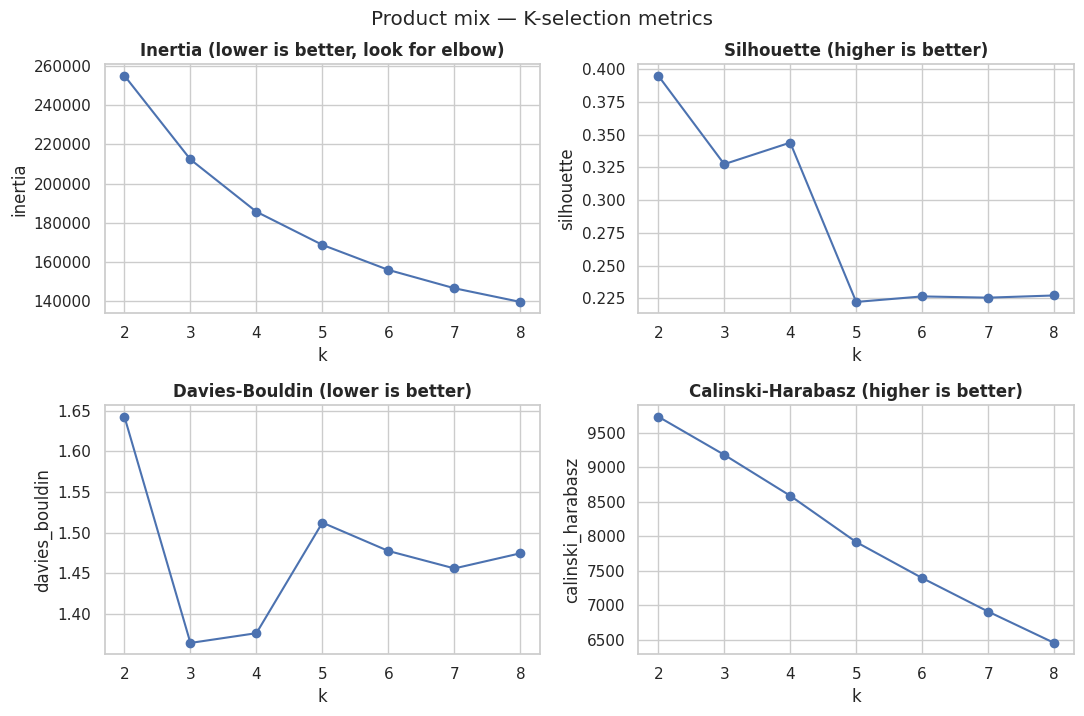

In [15]:
viz.plot_k_metrics(metrics_p)
plt.suptitle("Product mix — K-selection metrics", y=1.02)
save_fig(plt.gcf(), "19_mix_k_metrics")
plt.show()

**Choosing K=4 for the mix perspective.** The silhouette tells a more interesting story than "K=2 wins":

| K | silhouette |
|---|-----------|
| 2 | 0.395 |
| 3 | 0.327 |
| 4 | **0.344** |
| 5 | 0.222 |

Silhouette is highest at K=2, but the curve is non-monotonic: it *drops* at K=3 and then *recovers* at K=4 before collapsing at K=5. That recovery — K=4 sits at a clear local maximum, 0.12 above K=5 — is a real geometric signal that there is genuine four-cluster structure on top of the two-cluster grocery-vs-everything-else split. Davies-Bouldin agrees, showing its smallest values at K=3 and K=4 then deteriorating. The choice of K=4 over K=2 is therefore not a pure interpretability override of the silhouette; it is selecting the local maximum that surfaces the tech, family-provisioner and young-parents niches K=2 would hide. We accept a silhouette cost against the global K=2 peak (0.395 vs 0.344) in exchange for resolving structure the K=2 split aggregates away.

In [16]:
K_MIX = 4
km_p, labels_p = clu.fit_kmeans(Xp, n_clusters=K_MIX)
df["mix_cluster"] = labels_p
clu.cluster_sizes(labels_p)

0     5256
1     2765
2     3440
3    21577
Name: count, dtype: int64

In [17]:
stab_p = clu.stability_across_seeds(Xp, n_clusters=K_MIX)
print(f"Mix stability: mean ARI = {stab_p['mean_ari']:.4f}, min = {stab_p['min_ari']:.4f}")

Mix stability: mean ARI = 1.0000, min = 1.0000


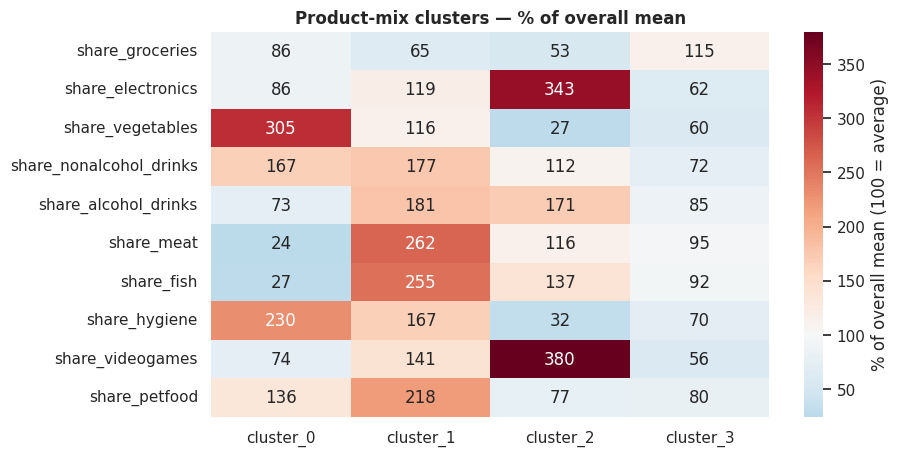

,cluster_0,cluster_1,cluster_2,cluster_3
share_groceries,86.5,65.4,53.4,115.2
share_electronics,86.0,119.0,343.4,62.2
share_vegetables,305.3,115.9,26.6,59.7
share_nonalcohol_drinks,167.1,177.1,111.7,71.9
share_alcohol_drinks,72.7,180.9,170.6,85.0
share_meat,24.4,262.5,115.9,95.1
share_fish,27.3,254.6,137.3,92.0
share_hygiene,230.5,167.0,32.3,70.4
share_videogames,73.6,141.0,380.2,56.5
share_petfood,135.5,218.4,76.7,79.9


In [18]:
profile_p = clu.cluster_profile(df, labels_p, cfg.PRODUCT_MIX_FEATURES)
fig, ax = plt.subplots(figsize=(9, 5))
viz.plot_cluster_heatmap(profile_p, title="Product-mix clusters — % of overall mean", ax=ax)
save_fig(fig, "20_mix_profile")
plt.show()
profile_p

In [19]:
mix_map = clu.name_mix_clusters(df)
print("Cluster ID -> content-based name:")
for cid, name in mix_map.items():
    print(f"  cluster {cid} -> {name}")

Cluster ID -> content-based name:
  cluster 2 -> tech
  cluster 1 -> family_provisioner
  cluster 0 -> young_parents
  cluster 3 -> grocery_generalist


### Compositional-data check (CLR)

The product-mix features are *compositional*: each row sums to 1, and each value is constrained to [0, 1]. K-Means with Euclidean distance is not the natural choice for data on the simplex — the textbook move is the **centred log-ratio (CLR) transformation**, which maps the simplex to Euclidean space:

$$\mathrm{clr}(x_i) = \log\!\left(\frac{x_i}{g(x)}\right)$$

where $g(x)$ is the geometric mean of the row. After CLR, Euclidean K-Means is geometrically appropriate.

We rerun K-Means on the CLR-transformed shares and compare against the raw-shares result using ARI. If both transformations produce essentially the same partition, our raw-shares K-Means is defensible despite the geometric objection. If they diverge substantially, we should switch.

In [20]:
share_cols = [c for c in df.columns if c.startswith("share_")]
clr_df = bl.clr_transform(df[share_cols])
df_clr = pd.concat([df, clr_df], axis=1)
clr_features = clr_df.columns.tolist()

scaler_clr, X_clr = clu.scale_perspective(df_clr, clr_features)
_, labels_clr = clu.fit_kmeans(X_clr, n_clusters=K_MIX)

ari_clr = bl.compare_segmentations(labels_p, labels_clr)
print(f"ARI between raw-shares and CLR K-Means: {ari_clr:.3f}")

# Side-by-side cluster sizes
comp = pd.DataFrame({
    "raw_shares": pd.Series(labels_p).value_counts().sort_index(),
    "clr_shares": pd.Series(labels_clr).value_counts().sort_index(),
})
print("\nCluster size comparison:")
print(comp)

ARI between raw-shares and CLR K-Means: 0.417

Cluster size comparison:
   raw_shares  clr_shares
0        5256        5953
1        2765         701
2        3440       18489
3       21577        7895


In [21]:
# The real comparison: where do raw-shares cluster members land under CLR?
# (Names are attached only to make the table readable - the agreement
#  evidence is the ARI and this crosstab, not the fact that the naming
#  function returns four names, which it always does by construction.)
df_clr["clr_cluster"] = labels_clr
clr_named = df_clr["clr_cluster"].map(clu.name_mix_clusters(df_clr, label_col="clr_cluster"))
raw_named = df["mix_cluster"].map(mix_map)

xtab = pd.crosstab(raw_named, clr_named)
print("rows = raw-shares cluster, cols = CLR cluster (customer counts)")
print(xtab.to_string())

diag = sum(xtab.loc[n, n] for n in xtab.index if n in xtab.columns)
print(f"\nCustomers keeping the same-named cluster under CLR: "
      f"{diag:,} of {len(df):,} ({diag/len(df):.1%})")
print("A high ARI would mean CLR was unnecessary; 0.417 means the geometric "
      "objection is real and the two partitions agree only partly.")

rows = raw-shares cluster, cols = CLR cluster (customer counts)
clr_cluster         family_provisioner  grocery_generalist  tech  young_parents
mix_cluster                                                                    
family_provisioner                1659                  27   993             86
grocery_generalist               16470                 512  1861           2734
tech                               185                  82  2993            180
young_parents                      175                  80   106           4895

Customers keeping the same-named cluster under CLR: 10,059 of 33,038 (30.4%)
A high ARI would mean CLR was unnecessary; 0.417 means the geometric objection is real and the two partitions agree only partly.


An ARI of 0.417 is **genuine partial agreement, and nothing stronger**. The two methods do not carve the customer base the same way. Clusters have to be matched by membership, not by name: 16,470 of the 21,577 customers in the raw-shares grocery-generalist cluster land in a single large CLR cluster, while the CLR cluster that the naming function happens to label `grocery_generalist` holds only 701.

A caveat about how *not* to read this. It is tempting to run `name_mix_clusters` on the CLR labels, see the same four names come back, and call that agreement. That would be circular: the naming function assigns each of the four names exactly once, greedily, whatever the centroids look like — it **cannot** return a different set, so it can never provide evidence that two partitions match. The cell below makes the actual comparison, a cross-tabulation of where each raw-shares cluster's members end up under CLR.

The honest summary is that the two methods disagree substantially about which customers belong where. Whether CLR finds the same *kinds* of groups would need its centroids compared directly, which this notebook does not do — the names alone cannot show it, for the reason above. This is the expected behaviour on the simplex: Euclidean K-Means on raw shares treats a +0.10 shift in groceries-share as the same distance whether you start at 0.65 or 0.10, even though those are very different moves compositionally, and CLR removes that distortion.

We keep raw-shares K-Means as the headline because (i) the final segments are coarse enough that boundary disagreements are likely to be absorbed (not tested here) when `(promo_hunter, *)` collapses and tiny segments fold; (ii) raw shares are directly interpretable in the report as "share of wallet"; and (iii) whichever boundary raw-shares K-Means picks, it picks it perfectly consistently across seeds (mean ARI 1.000) — consistency, not proof of correctness. The CLR result stands as a documented limitation, not as a switch we should make.

## 3. Demographic perspective (descriptive only)

Features: age, kids and teens at home, complaints, hour-of-day (cyclic), loyalty card, degree one-hots, gender.

### Up front: this perspective largely recovers the `degree` column

The cluster profile below confirms each cluster is essentially "graduates of one degree level" plus a non-graduate group. Because the perspective adds little independent information over the `degree` feature already in `customer_info`, **we do not use it as a primary axis in the final segment assignment, do not persist its scaler or K-Means model with the other artefacts, and do not include `demo_cluster` in `customer_segments.csv`.**

It is shown here because the brief asks for demographic analysis, and confirming that demographics in this dataset *is* degree is itself a finding worth documenting. Demographic context is also useful as a *descriptor* layered on top of the final segments (e.g. "Promo Hunter customers skew non-graduate").

In [22]:
scaler_d, Xd = clu.scale_perspective(df, cfg.DEMOGRAPHIC_FEATURES)
metrics_d = clu.evaluate_k_range(Xd, k_range=range(2, 9))
metrics_d.round(3)

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,331302.180,0.182,2.211,6496.854
3,292181.001,0.234,1.899,5894.847
4,253136.423,0.286,1.481,6234.344
5,228640.460,0.230,1.646,6061.321
6,213928.710,0.216,1.682,5636.685
7,201845.700,0.221,1.582,5307.829
8,193177.989,0.207,1.593,4965.275


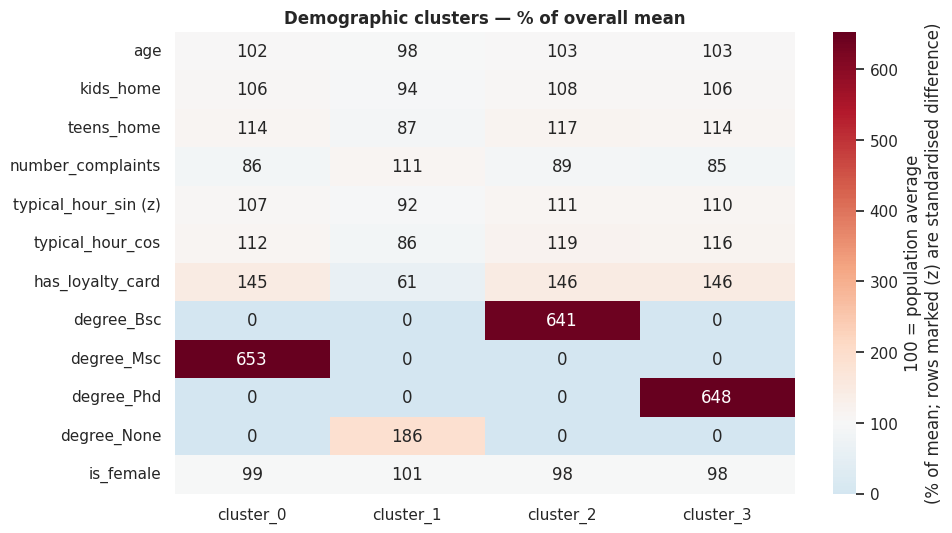

,cluster_0,cluster_1,cluster_2,cluster_3
age,102.1,97.6,103.2,103.0
kids_home,105.9,94.1,108.0,106.5
teens_home,114.1,87.1,116.8,113.8
number_complaints,86.4,111.3,88.8,85.4
typical_hour_sin,107.0,92.0,110.6,110.1
typical_hour_cos,111.9,86.3,119.2,116.4
has_loyalty_card,144.8,60.7,146.0,146.0
degree_Bsc,0.0,0.0,641.0,0.0
degree_Msc,653.3,0.0,0.0,0.0
degree_Phd,0.0,0.0,0.0,648.3


In [23]:
K_DEMO = 4
km_d, labels_d = clu.fit_kmeans(Xd, n_clusters=K_DEMO)
df["demo_cluster"] = labels_d  # for the descriptive check below only

profile_d = clu.cluster_profile(df, labels_d, cfg.DEMOGRAPHIC_FEATURES)
fig, ax = plt.subplots(figsize=(10, 6))
viz.plot_cluster_heatmap(profile_d, title="Demographic clusters — % of overall mean", ax=ax)
save_fig(fig, "21_demo_profile")
plt.show()
profile_d

In [24]:
demo_map = clu.name_demo_clusters(df)
print("Demo cluster ID -> dominant degree:")
for cid, name in demo_map.items():
    print(f"  cluster {cid} -> {name}")

df["demo_named"] = df["demo_cluster"].map(demo_map)
crosstab = pd.crosstab(df["demo_named"], df["degree"], normalize="index").round(3)
print("\nDegree composition of each demo cluster:")
print(crosstab)

Demo cluster ID -> dominant degree:
  cluster 0 -> demo_msc
  cluster 1 -> demo_none
  cluster 2 -> demo_bsc
  cluster 3 -> demo_phd

Degree composition of each demo cluster:
degree      Bsc  Msc  None  Phd
demo_named                     
demo_bsc    1.0  0.0   0.0  0.0
demo_msc    0.0  1.0   0.0  0.0
demo_none   0.0  0.0   1.0  0.0
demo_phd    0.0  0.0   0.0  1.0


The crosstab is not "mostly" one degree per cluster — it is **exactly 100% / 0%** in every cell. The demographic perspective is `groupby('degree')` with K-Means dressing. This is a result of the modelling rather than a finding about the dataset. After standardisation, a one-hot column with share *p* jumps by 1/√(p(1−p)) standard deviations between 0 and 1 — at least 2, and around 3 for the rarer degrees — and a change of degree moves two such columns at once, which swamps the other demographic features in the Euclidean distance. Seeing any other demographic structure would require down-weighting the one-hot columns. We carry the perspective forward as descriptive context only.

## 4. Visual check with t-SNE

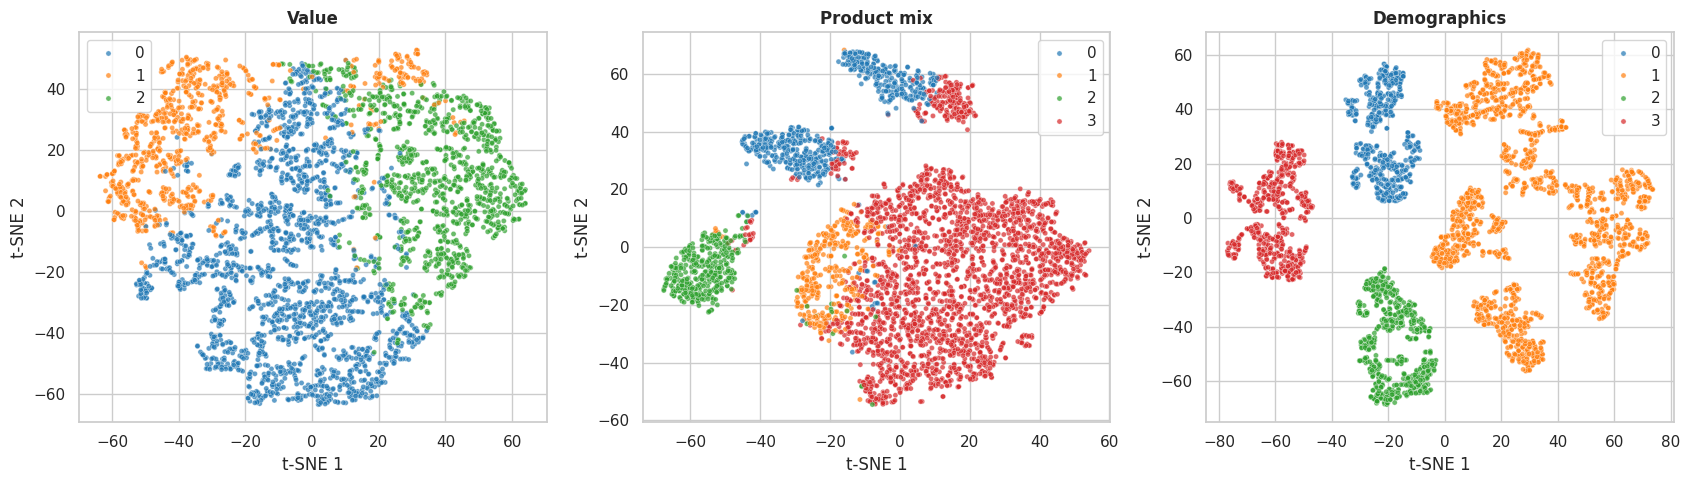

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
viz.tsne_scatter(Xv, labels_v, sample_size=4000, title="Value", ax=axes[0])
viz.tsne_scatter(Xp, labels_p, sample_size=4000, title="Product mix", ax=axes[1])
viz.tsne_scatter(Xd, labels_d, sample_size=4000, title="Demographics", ax=axes[2])
plt.tight_layout()
save_fig(fig, "22_tsne_perspectives")
plt.show()

Reading the three panels:

- **Demographics (right)** shows clean, well-separated islands — but this is not because the demographic clustering is "better". It is because the perspective is dominated by one-hot encoded degree, which is discrete by construction and projects to discrete blobs. The clean separation here is a sign the perspective is recovering an existing column, not finding latent structure (we already disclosed this in section 3).
- **Product mix (middle)** is mostly clean with one dominant blob plus three smaller groups, consistent with the K=4 profile and with the relatively healthy silhouette of 0.34.
- **Value (left)** is the fuzziest of the three. Heavy interleaving of all three colours with no clean gaps. This reflects the modest silhouette (~0.24) honestly disclosed in the limitations section: the value clusters exist and are reproducible across seeds (mean pairwise ARI > 0.99), but the boundaries are genuinely soft. Some of the apparent bleed-through is also t-SNE distortion — projecting 5D down to 2D cannot preserve every distance — but the underlying fuzziness is real.

Two important thing about reading any t-SNE plot: it is a 2D visualization, not the space K-Means actually used (the clustering happened in the full feature space, so apparent overlap can be projection distortion rather than misassignment); and t-SNE preserves local neighbourhoods at the cost of global geometry. The plot is useful as a  check that something cluster-like exists in the data, but the per-cluster profile heatmaps above are what actually demonstrate the clusters are interpretable.

## 5. Final segment assignment

We combine the named value and named mix labels into a final segment using `assign_final_segments`. This second stage is a **deliberate business-rule overlay**, not a clustering algorithm, and we are explicit about that. The two perspectives are learned by K-Means; the lookup table (`FINAL_SEGMENT_LOOKUP` in `clustering.py`) is the documented mapping a marketing team would apply to turn those two learned axes into named, actionable segments.

Two business decisions are encoded in the lookup, and both are defensible:

1. **All four `(promo_hunter, *)` cells collapse to a single `Promo Hunter` segment.** For the promo-driven tier, promo-seeking behaviour dominates product mix: a deal-chaser is best served by deal-driven offers regardless of which categories they lean toward.
2. **Tiny segments (< 200 customers) are folded into their generalist counterpart**, because a 124-customer segment cannot support a real campaign.

The lookup uses the content-based names, so the result is identical across runs even if the K-Means integer IDs shuffle. In section 5b we cross-check this hand-authored merge against a *learned* merge to show the business rules are not arbitrary.

In [26]:
segments, naming = clu.assign_final_segments(df)
df["segment"] = segments

print("Final segment sizes:")
print(segments.value_counts())
print()
print(f"Total segments: {segments.nunique()}")
print()
if naming["folded"]:
    print("Segments folded into generalist (too small for separate campaigns):")
    for old, new in naming["folded"].items():
        print(f"  {old} -> {new}")

Final segment sizes:
segment
Engaged Generalist            8336
Routine Generalist            8075
Promo Hunter                  6999
Routine Young Parents         4921
Routine Tech                  3147
Routine Family Provisioner     966
Engaged Family Provisioner     594
Name: count, dtype: int64

Total segments: 7

Segments folded into generalist (too small for separate campaigns):
  Engaged Young Parents -> Engaged Generalist
  Engaged Tech -> Engaged Generalist


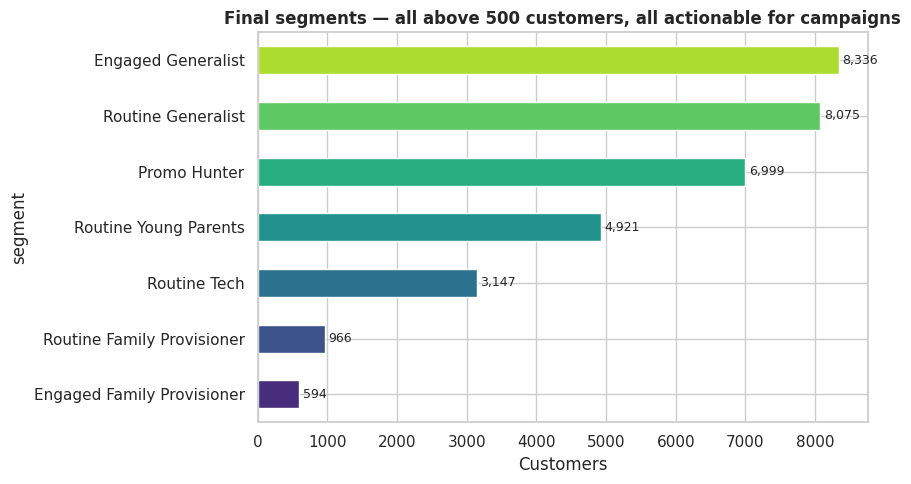

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sizes = segments.value_counts().sort_values(ascending=True)
colors = sns.color_palette("viridis", len(sizes))
sizes.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Customers")
ax.set_title("Final segments — all above 500 customers, all actionable for campaigns")
for i, v in enumerate(sizes.values):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, "23_final_segment_sizes")
plt.show()

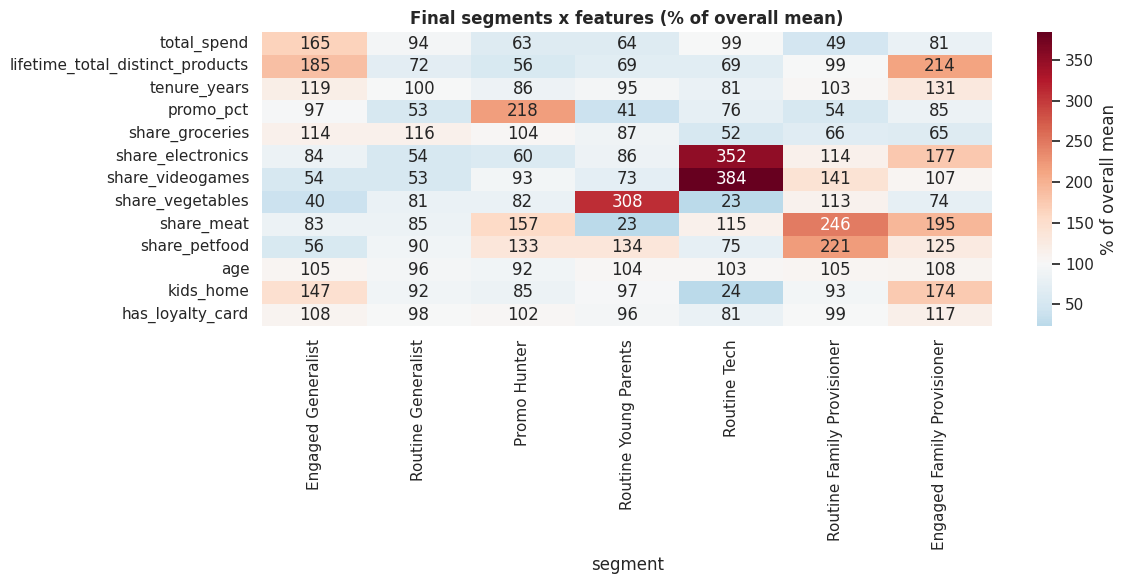

In [28]:
profile_cols = [
    "total_spend", "lifetime_total_distinct_products", "tenure_years",
    "promo_pct", "share_groceries", "share_electronics",
    "share_videogames", "share_vegetables", "share_meat",
    "share_petfood", "age", "kids_home", "has_loyalty_card",
]
relative_profile = (df.groupby("segment")[profile_cols].mean()
                    / df[profile_cols].mean() * 100).round(0).T

seg_order = df["segment"].value_counts().index
relative_profile = relative_profile[seg_order]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(relative_profile, center=100, cmap="RdBu_r",
            annot=True, fmt=".0f",
            cbar_kws={"label": "% of overall mean"}, ax=ax)
ax.set_title("Final segments x features (% of overall mean)")
plt.tight_layout()
save_fig(fig, "24_final_segment_profile")
plt.show()

### What is inside the Promo Hunter segment?

Because the final-segment lookup collapses all four `(promo_hunter, *)` combinations into a single "Promo Hunter" segment, it is worth checking what mix-cluster types actually sit inside it. If 99% are grocery-generalist, the collapse is fine; if it is split four ways, we are hiding meaningful sub-structure.

In [29]:
ph_mask = df["segment"] == "Promo Hunter"
ph_mix_counts = df.loc[ph_mask, "mix_cluster"].map(mix_map).value_counts()
ph_mix_pct = (ph_mix_counts / ph_mix_counts.sum() * 100).round(1)
ph_table = pd.DataFrame({"customers": ph_mix_counts, "% of Promo Hunter": ph_mix_pct})
print(f"Promo Hunter total: {int(ph_mask.sum()):,} customers")
print()
print(ph_table.to_string())

Promo Hunter total: 6,999 customers

                    customers  % of Promo Hunter
mix_cluster                                     
grocery_generalist       5419               77.4
family_provisioner       1205               17.2
young_parents             206                2.9
tech                      169                2.4


The Promo Hunter segment is dominated by grocery-generalist shoppers (~77%) with a secondary cluster of family-provisioner customers (~17%). The tech and young-parents tails together are under 6%, too small to support separate campaigns within the promo tier. So the lookup's decision to collapse `(promo_hunter, *)` into one segment is empirically justified: promo behaviour really is the dominant signal for this tier, and the product-mix variation inside the segment is too thin and too skewed toward "general groceries" to warrant splitting. A marketer wanting to add a small targeted bonus could optionally treat the ~17% family-provisioner sub-group as a secondary creative variant, but they would be running essentially the same campaign with a swapped product hero.

### 5b. Cross-check: a learned merge instead of the lookup

To show the business-rule lookup is not arbitrary, we also build a **learned** second-stage merge: form the joint value x mix groups, take each group's centroid in the standardised joint feature space, run Ward agglomerative clustering on those centroids, and cut to the same number of final groups. If the learned merge lands close to our lookup, that is evidence the lookup encodes real structure rather than wishful grouping. We measure closeness with the Adjusted Rand Index.

In [30]:
merged_learned = clu.learned_merge_labels(df, n_final=df["segment"].nunique())
ari_merge = bl.compare_segmentations(df["segment"], merged_learned)
print(f"Number of learned-merge groups: {merged_learned.nunique()}")
print(f"ARI(business-rule lookup, learned Ward merge) = {ari_merge:.3f}")
print()
print("Learned-merge group sizes:")
print(merged_learned.value_counts().sort_index().to_string())

Number of learned-merge groups: 7
ARI(business-rule lookup, learned Ward merge) = 0.621

Learned-merge group sizes:
merged_group
1     5256
2    16158
3     5419
4     2171
5      718
6     3147
7      169


An ARI in the 0.6 range means the learned merge and the business-rule lookup agree on the large majority of customer pairings. They are not identical, the learned merge does not know about the deliberate `promo_hunter` collapse, and it splits on the joint geometry rather than on marketing logic, but the substantial agreement confirms the lookup is a reasonable, defensible grouping of the two learned axes rather than an arbitrary hand-authored table. We keep the lookup as the headline because it is more interpretable and lets us encode the promo-tier decision explicitly; the learned merge is reported here as corroboration.

## 6. Baseline comparison: does the clustering beat a simple heuristic?

If a simple heuristic produced the same segments as K-Means, the ML would not be adding value. We build an **RFM-style** baseline with quantile binning on three columns. Only the monetary part is genuine RFM: the data has no recency, so the first bin is **tenure** (time since the *first* purchase, not the last), and the second is `distinct_stores_visited`, which measures breadth rather than frequency. A real frequency measure (invoices per customer) exists in `customer_basket`, but only for the 85% of customers who have baskets, so it is not used. The 27 cells are collapsed into named buckets and compared with our clustering by Adjusted Rand Index.

All three bins participate in the collapse rule. That is worth stating because an earlier version of `coarse_rfm_label` unpacked the first (tenure) bin and then never used it, which quietly made this a two-bin baseline — a weaker comparison than advertised. The crosstab below against `r_bin` is the check that the tenure bin is actually doing work.

How to read the result: ARI near 0.7+ would mean K-Means is rediscovering RFM and the modelling was wasted. ARI near 0 would mean the clusters are unrelated to any sensible notion of customer value, which would be its own worry. Something in between means the two agree on broad shape while K-Means picks up structure RFM cannot see.

In [31]:
rfm = bl.rfm_segments(df)
df["rfm_label"] = bl.coarse_rfm_label(rfm)

print("RFM heuristic segments (size):")
print(df["rfm_label"].value_counts().to_string())

print("\nRecency-bin composition per label (proof R participates in the rule):")
print(pd.crosstab(df["rfm_label"], rfm["r_bin"], normalize="index").round(2).to_string())

RFM heuristic segments (size):
rfm_label
rfm_middle                     17751
rfm_many_stores                 6174
rfm_high_value                  5675
rfm_long_tenure_many_stores     2013
rfm_new_low_spend               1425

Recency-bin composition per label (proof R participates in the rule):
r_bin                           1     2     3
rfm_label                                    
rfm_high_value               0.00  0.35  0.65
rfm_long_tenure_many_stores  0.00  0.00  1.00
rfm_many_stores              0.58  0.42  0.00
rfm_middle                   0.34  0.36  0.30
rfm_new_low_spend            1.00  0.00  0.00


In [32]:
ari_rfm_vs_kmeans = bl.compare_segmentations(df["rfm_label"], df["segment"])
print(f"Adjusted Rand Index, RFM vs K-Means segmentation: {ari_rfm_vs_kmeans:.3f}")

crosstab = pd.crosstab(df["segment"], df["rfm_label"], normalize="index").round(2)
print("\nFraction of each K-Means segment in each RFM bucket:")
print(crosstab)

Adjusted Rand Index, RFM vs K-Means segmentation: 0.093

Fraction of each K-Means segment in each RFM bucket:
rfm_label                   rfm_high_value  rfm_long_tenure_many_stores  \
segment                                                                   
Engaged Family Provisioner            0.09                         0.25   
Engaged Generalist                    0.56                         0.04   
Promo Hunter                          0.02                         0.12   
Routine Family Provisioner            0.00                         0.05   
Routine Generalist                    0.09                         0.03   
Routine Tech                          0.03                         0.00   
Routine Young Parents                 0.01                         0.08   

rfm_label                   rfm_many_stores  rfm_middle  rfm_new_low_spend  
segment                                                                     
Engaged Family Provisioner             0.18        0.47     

A note on interpreting this ARI. It sits just under 0.1 — close to the "near 0" region the section introduction said would be its own worry — so it needs a careful reading rather than being called a good outcome.

Two things are going on. First, the heuristic and K-Means do share a broad engagement axis: the crosstab shows K-Means engaged customers concentrating in the high-value bucket, so the clusters are not unrelated to customer value. Second, most of the final segmentation is driven by product mix, which a tenure/stores/spend heuristic cannot see at all — the tech, young-parents and family-provisioner splits all fall into the same heuristic buckets. That second effect alone is enough to hold the ARI down, whatever the quality of the clustering.

The honest caveat: a low ARI on its own does not prove the extra structure is *useful*, only that it is *different*. What supports usefulness is the per-segment basket evidence in notebook 04, where the segments turn out to have genuinely distinct product signatures.

## 7. Save everything

We save:

- the per-customer segment assignment to `outputs/customer_segments.csv` (required deliverable) with `customer_id`, `segment`, `value_cluster`, `mix_cluster`. **`demo_cluster` is not included** because the demographic perspective is descriptive context, not a segmentation axis.
- the fitted scalers, KMeans models, and integer-to-name mappings for the value and mix perspectives, so a new customer can be classified later via `predict_segment` without re-running the whole notebook.

In [33]:
out = df[["customer_id", "segment", "value_cluster", "mix_cluster"]].copy()
print("Customers in output:", len(out))
print("All original customers covered:", out["customer_id"].nunique() == len(raw))
print("Columns in output:", out.columns.tolist())

cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out.to_csv(cfg.FINAL_SEGMENTS_CSV, index=False)
print(f"\nSaved {cfg.FINAL_SEGMENTS_CSV.relative_to(cfg.PROJECT_ROOT)}")

# Full annotated frame for downstream notebooks/app - identifiers stripped,
# same as notebook 02. Nothing persisted carries name, birthdate or location.
annotated = pp.drop_identifiers(df)
leaked = [c for c in cfg.IDENTIFIER_COLUMNS + cfg.SUPERSEDED_COLUMNS if c in annotated.columns]
assert not leaked, f"identifier columns would be persisted: {leaked}"
annotated.to_parquet(cfg.OUTPUT_DIR / "customer_info_with_segments.parquet")
print(f"Saved annotated frame ({annotated.shape[0]:,} x {annotated.shape[1]}), "
      f"identifiers dropped: {sorted(set(df.columns) - set(annotated.columns))}")

Customers in output: 33038
All original customers covered: True
Columns in output: ['customer_id', 'segment', 'value_cluster', 'mix_cluster']

Saved outputs/customer_segments.csv


Saved annotated frame (33,038 x 50), identifiers dropped: ['customer_birthdate', 'customer_name', 'latitude', 'longitude', 'loyalty_card_number']


In [34]:
# Persist the value + mix models, the naming maps, and the frozen
# preprocessing parameters (demographic perspective excluded - see section 3).
#
# The preprocessing params are the piece that makes scoring batch-independent:
# without them, inference would recompute imputation medians and the 99th
# percentile spend caps from whatever rows it happened to be given.
models_dir = clu.save_models(
    scaler_v, km_v, scaler_p, km_p,
    value_map, mix_map,
    naming["folded"],
    preproc_params=preproc_params,
)
print(f"Saved models to {models_dir.relative_to(cfg.PROJECT_ROOT)}")
for f in sorted(p.name for p in models_dir.iterdir()):
    print("  ", f)

Saved models to outputs/models
   cluster_naming.json
   kmeans_mix.joblib
   kmeans_value.joblib
   preprocessing_params.json
   scaler_mix.joblib
   scaler_value.joblib


In [35]:
# Full validation: re-classify every customer with predict_segment (which
# uses ONLY the persisted models, no notebook state) and confirm the result
# matches the segment label assigned during fitting. If even one row
# disagrees, the persistence/inference path is broken.
predicted = clu.predict_segment(df)
n_total = len(predicted)
n_match = int((predicted["segment"].values == df["segment"].values).sum())
print(f"predict_segment validated on all {n_total:,} customers")
print(f"matches the in-pipeline assignment for {n_match:,} of {n_total:,} rows "
      f"({n_match/n_total:.2%})")

assert n_match == n_total, (
    f"predict_segment / in-pipeline disagreement on "
    f"{n_total - n_match} rows - persistence is broken"
)
print()
print("Distribution of predicted segments:")
print(predicted['segment'].value_counts().to_string())

predict_segment validated on all 33,038 customers
matches the in-pipeline assignment for 33,038 of 33,038 rows (100.00%)

Distribution of predicted segments:
segment
Engaged Generalist            8336
Routine Generalist            8075
Promo Hunter                  6999
Routine Young Parents         4921
Routine Tech                  3147
Routine Family Provisioner     966
Engaged Family Provisioner     594


### Scoring must not depend on batch composition

`predict_segment` reproducing the training labels proves the *models* round-trip. It does not prove the *preprocessing* does, because the training run and the validation above both see all 33,038 rows.

The sharper test is whether a customer's segment is a property of that customer or a property of the file they arrived in. We re-score the same 300 customers three ways: alone, inside a random slice, and inside the full population. With frozen medians and caps these must agree exactly. (They did not before those statistics were persisted — customers near a spend cap could flip segment depending on batch size.)

In [36]:
rng = np.random.default_rng(cfg.RANDOM_STATE)

# Pick the customers most exposed to the capping step: anyone in the top 1%
# of at least one capped spend column. If batch composition matters anywhere,
# it matters here.
capped_cols = pp.capped_spend_columns()
exposed = np.zeros(len(raw), dtype=bool)
for col in capped_cols:
    exposed |= (raw[col] >= raw[col].quantile(0.99)).fillna(False).to_numpy()
probe_idx = rng.choice(np.flatnonzero(exposed), size=300, replace=False)
probe = raw.iloc[probe_idx]

truth = df.set_index("customer_id")["segment"]
models = clu.load_models()

def score(sub):
    feats = pp.build_features(sub, models["preproc_params"])
    got = clu.predict_segment(feats, models=models)["segment"]
    return pd.Series(got.values, index=sub["customer_id"].values)

contexts = {
    "the 300 alone":              probe,
    "inside a random 2,000":      pd.concat([probe, raw.drop(probe.index).sample(1700, random_state=1)]),
    "inside the full 33,038":     raw,
    "one row at a time (first 5)": None,
}

print(f"{'batch context':30s}  agreement with the training-run label")
print("-" * 72)
for label, ctx in contexts.items():
    if ctx is None:
        single = pd.concat([score(probe.iloc[[i]]) for i in range(5)])
        agree = (single == truth.reindex(single.index)).mean()
        print(f"{label:30s}  {agree:>7.2%}   (n=5)")
        continue
    got = score(ctx).reindex(probe["customer_id"].values)
    agree = (got == truth.reindex(got.index)).mean()
    print(f"{label:30s}  {agree:>7.2%}   (n={len(got)})")

full = score(raw)
overall = (full == truth.reindex(full.index)).mean()
print(f"\nAll {len(raw):,} customers re-scored through the frozen-params path: {overall:.2%}")
assert overall == 1.0, "frozen preprocessing does not reproduce the training labels"
print("Batch composition has no effect on a customer's segment.")

batch context                   agreement with the training-run label
------------------------------------------------------------------------
the 300 alone                   100.00%   (n=300)
inside a random 2,000           100.00%   (n=300)


inside the full 33,038          100.00%   (n=300)
one row at a time (first 5)     100.00%   (n=5)



All 33,038 customers re-scored through the frozen-params path: 100.00%
Batch composition has no effect on a customer's segment.


## 8. Summary and limitations

**Results**

- Three perspectives evaluated, two used in the final segmentation. K-Means with K = 3 (value) and K = 4 (mix).
- Cluster naming based on centroid content, not integer IDs, so labels are reproducible across runs.
- Stability across 6 random seeds confirmed via pairwise ARI: mean > 0.99 for both perspectives.
- Tiny segments (< 200 customers) folded into generalist counterparts, leaving 7 actionable segments.
- Baseline RFM-style comparison (tenure, stores, spend) via ARI; the low value mostly reflects product-mix structure the heuristic cannot see.
- CLR compositional-data comparison run for the mix perspective; ARI 0.417 means partial agreement only, documented as a limitation rather than resolved.
- Models, naming maps **and the frozen preprocessing parameters** persisted to `outputs/models/`, so `predict_segment` gives a customer the same answer regardless of what else is in the batch.

**Limitations**

- Silhouettes are in the 0.24-0.34 range across perspectives, indicating soft rather than well-separated clusters. The clusters are *stable* (mean ARI > 0.99 across seeds) rather than *tight*, and the per-cluster heatmaps carry the interpretability that geometric separation does not.
- The two smallest surviving segments, **Routine Family Provisioner** (966 customers, 2,754 baskets) and **Engaged Family Provisioner** (594 customers, 1,793 baskets), have thin basket evidence. Association rules there rest on 36-163 (Engaged Family Provisioner) and 56-97 (Routine Family Provisioner) supporting baskets rather than several hundred; notebook 04 reports the counts and marks the designs that lean on the spend profile.
- The product-mix perspective runs Euclidean K-Means on compositional data. The CLR check above shows this is a real approximation (ARI 0.417), not a formality.
- **The spend-share profiles and the basket contents do not describe the same behaviour.** Notebook 04 measures this directly: across all ten categories the per-customer rank correlation between spend share and basket-item share is between -0.19 and +0.05, i.e. never meaningfully positive. Any statement of the form "this segment's spend profile says X, so promote X" is therefore supported by `customer_info` alone and *not* corroborated by `customer_basket`. This is almost certainly an artefact of how the synthetic course data was generated, but it bounds how far the segment identities can be pushed into basket-level campaign design.
- All customers live within Lisbon, so geography carries no clustering signal; results may not generalise to multi-city retailers.
- The demographic perspective comes out as exactly the `degree` column (100% per cluster) because the standardised one-hot degree columns dominate the distance. A modelling artefact, reported rather than hidden.
- The grid structure is a modelling choice with a cost: the 3x4 design buys interpretability but imposes a grid the data does not necessarily have. A flat joint clustering might express structure the grid cannot (the Promo Hunter collapse, for example, absorbs a 1,205-customer family-provisioner group); this was not tested here.

All 33,038 customers are assigned to a named segment. The next notebook uses this to drive per-segment association rules and promotion design.